# The type-I seesaw in `feynlag`: Majorana neutrino masses, step by step

Neutrinos are massless in the Standard Model.  The **type-I seesaw** is the
simplest way to give them mass: add right-handed neutrinos $\nu_R$ (complete
gauge singlets) with

- a **Dirac Yukawa** $-Y_\nu \bar L \tilde H\, \nu_R$ (like every other fermion), and
- a **Majorana mass** $-\tfrac12 M_R\, \nu_R^T C \nu_R$ — *allowed* precisely
  because $\nu_R$ carries no gauge charge, and the origin of the mechanism.

After electroweak symmetry breaking the neutral-fermion mass matrix, in the
left-handed basis $n = (\nu_L,\ \nu_R^c)$, is

$$M_\nu = \begin{pmatrix} 0 & m_D \\ m_D^T & M_R \end{pmatrix},\qquad m_D = Y_\nu v/\sqrt2.$$

For $M_R \gg m_D$ this **seesaws**: a naturally tiny light neutrino
$m_\nu \approx -m_D M_R^{-1} m_D^T$ and a heavy state $\approx M_R$, mixed by
$V \approx m_D M_R^{-1}$.  This notebook walks the whole construction in feynlag
— including extracting the physical heavy-neutrino couplings, which requires the
Majorana machinery (`diracC`, `MajoranaBilinear`) and a charge-conjugation-aware
mass-basis rotation, because the physical neutrinos are Majorana fields mixing
$\nu_L$ with the charge-conjugate $\nu_R^c$.

We use one generation for transparency; the machinery is generation-general.

## 1. Symmetries, parameters, fields

In [ ]:
import sympy as sp
sp.init_printing()

from feynlag import (
    Bilinear, DiracGamma, Dmu, ExternalParameter, InternalParameter, Lagrangian,
    MajoranaBilinear, MajoranaRotation, Model, Rotation, SU2, Scalar, U1,
    WeylFermion, dag, diagonalize_takagi, diracC, diracPL, diracPR,
    extract_fermion_vertices, fermion_gauge_current, fermion_mass_matrix,
    majorana_mass_matrix, rotation_2x2, seesaw_light_mass, seesaw_mass_matrix,
)

gw = ExternalParameter("gw", 0.6535, positive=True)
g1 = ExternalParameter("g1", 0.3580, positive=True)
SU2L, U1Y = SU2("SU2L", coupling=gw), U1("U1Y", coupling=g1)
v = ExternalParameter("v", 246.0, positive=True, unit_dim=1)
lam = ExternalParameter("lam", 0.129)
mu2 = InternalParameter("mu2", unit_dim=2)
yv = ExternalParameter("yv", 0.01, positive=True)              # Dirac Yukawa
MR = ExternalParameter("MR", 1.0e3, positive=True, unit_dim=1)  # seesaw scale

The right-handed neutrino is a **total singlet** — `reps={}` — which is exactly
what lets it carry a bare Majorana mass (nothing forbids $\nu_R^T C \nu_R$).

In [ ]:
H = Scalar("H", reps={SU2L: 2, U1Y: sp.Rational(1, 2)}, component_names=["Gp", "H0"])
H.expand_vev({H.components[1]: v})
Ll = WeylFermion("Ll", reps={SU2L: 2, U1Y: -sp.Rational(1, 2)}, chirality="L",
                 nflavors=1, component_names=["nuL", "eL"])
eR = WeylFermion("eR", reps={U1Y: -1}, chirality="R", nflavors=1, component_names=["eR"])
nuR = WeylFermion("nuR", reps={}, chirality="R", nflavors=1, component_names=["nuR"])
print("ν_R reps (total singlet):", nuR.reps)

ν_R reps (total singlet): {}


## 2. The neutrino Lagrangian

The Dirac Yukawa uses the conjugate doublet $\tilde H = (H^{0*},\,-H^{+*})$
(the same pattern as the up-type quarks).  The Majorana mass is written with the
`MajoranaBilinear` $\nu_R^T C\,P_L\,\nu_R$ — feynlag's charge-conjugation-aware
sandwich (the middle carries `diracC`, the charge-conjugation matrix $C=i\gamma^2\gamma^0$).

In [ ]:
i, j = sp.symbols("i j", integer=True)
Gp, H0 = H.components
nuL, eL = Ll.components
nuLbar, eLbar = Ll.bar_components
nR, nRbar = nuR.components[0], nuR.bar_components[0]
CPL = diracC * diracPL

# Dirac Yukawa via H̃:  −Y_ν L̄ H̃ ν_R + h.c.
LYukD = -(yv.s * sp.conjugate(H0) * Bilinear(nuLbar[i], diracPR, nR[j])
          + yv.s * (-sp.conjugate(Gp)) * Bilinear(eLbar[i], diracPR, nR[j]))
LYukD += -(sp.conjugate(yv.s) * H0 * Bilinear(nRbar[j], diracPL, nuL[i])
           + sp.conjugate(yv.s) * (-Gp) * Bilinear(nRbar[j], diracPL, eL[i]))

# Right-handed Majorana mass:  −½ M_R ν_Rᵀ C ν_R + h.c.
op = -sp.Rational(1, 2) * MR.s * MajoranaBilinear(nR[i], CPL, nR[j])
LMaj = op + sp.conjugate(op)

current = fermion_gauge_current(Ll, i) + fermion_gauge_current(eR, i)
display(MajoranaBilinear(nR[i], CPL, nR[j]))

## 3. Assemble the model and check invariance

In [ ]:
L = Lagrangian()
L.add((dag(Dmu(H)) * Dmu(H))[0], sector="kinetic")
L.add(-(-mu2.s * (dag(H) * H.mat)[0] + lam.s * (dag(H) * H.mat)[0]**2), sector="potential")
L.add(LYukD + current, sector="yukawa")
L.add(LMaj, sector="other")      # the Majorana mass — a mass term, not a vertex

model = Model("SM-seesaw", gauge_groups=[SU2L, U1Y],
              fields=[H, Ll, eR, nuR, SU2L.bosons("W"), U1Y.bosons("B")],
              parameters=[gw, g1, v, lam, mu2, yv, MR], lagrangian=L)
print(model.check_invariance())
model.check_invariance().raise_on_failure()
print("tadpole:", model.solve_tadpoles([mu2]))

InvarianceReport(16 checks, OK)


tadpole: {mu2: lam*v**2}


Gauge invariance passes: the Dirac Yukawa is a standard singlet-completing
coupling, and the Majorana mass is invariant because $\nu_R$ is a total singlet.
Now rotate the gauge bosons to the mass basis (Weinberg + $W^\pm$), as usual.

In [ ]:
W, B = SU2L.bosons(), U1Y.bosons()
W1, W2, W3 = W.components
B0 = B.components[0]
Z, A = sp.symbols("Z A", real=True)
model.rotate(Rotation([W3, B0], [Z, A], rotation_2x2(-sp.atan(g1.s / gw.s))))
Wp, Wm = sp.symbols("Wp Wm")
model.rotate(Rotation([W1, W2], [Wp, Wm],
                      sp.Matrix([[1, -sp.I], [1, sp.I]]) / sp.sqrt(2), kind="unitary"))

Rotation(SU2L_1→Wp, SU2L_2→Wm, kind='unitary')

## 4. The seesaw mass matrix

The Dirac block comes from the Yukawa (`fermion_mass_matrix`), the Majorana
block from `majorana_mass_matrix` (the symmetric $M_R$ — the D.2 Majorana
machinery), and `seesaw_mass_matrix` assembles the symmetric $6N\times6N$ block
form.

Dirac mass m_D = Y_ν v/√2: sqrt(2)*v*yv/2    Majorana mass M_R: MR


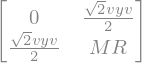

In [ ]:
mD = fermion_mass_matrix(LYukD, nuLbar, nR, model.vacuum, 1, (i, j), gamma=diracPR)
MRmat = majorana_mass_matrix(LMaj, nR, model.vacuum, 1, (i, j), gamma=CPL)
Mnu = seesaw_mass_matrix(mD, MRmat)
print("Dirac mass m_D = Y_ν v/√2:", mD[0, 0], "   Majorana mass M_R:", MRmat[0, 0])
Mnu

## 5. The seesaw formula and the spectrum

Block-diagonalising for $M_R \gg m_D$ gives the light neutrino mass
$m_\nu \approx -m_D M_R^{-1} m_D^T = -m_D^2/M_R$ — the **seesaw**: heavy $M_R$ in
the denominator makes $m_\nu$ tiny.  We check it against the *exact* Takagi
factorisation of the full matrix.

In [ ]:
print("seesaw formula  m_ν = −m_D²/M_R  =", sp.simplify(seesaw_light_mass(mD, MRmat)[0, 0]))

bench = {yv.s: 0.01, v.s: 246.0, MR.s: 1000.0, gw.s: 0.6535, g1.s: 0.3580}
Mn = sp.Matrix(2, 2, lambda a, b: sp.nsimplify(Mnu[a, b].subs(bench)))
U, D = diagonalize_takagi(Mn)     # M = U D Uᵀ, D ≥ 0 (Takagi, for Majorana)
masses = [abs(complex(sp.N(D[k, k]))) for k in range(2)]
light = 0 if masses[0] < masses[1] else 1
heavy = 1 - light
print(f"exact spectrum:  m_light = {masses[light]:.4e} GeV,  m_heavy = {masses[heavy]:.1f} GeV")
print(f"seesaw formula:  m_light = {abs(complex(sp.N(seesaw_light_mass(mD, MRmat)[0,0].subs(bench)))):.4e} GeV")

seesaw formula  m_ν = −m_D²/M_R  = -v**2*yv**2/(2*MR)


exact spectrum:  m_light = 3.0258e-03 GeV,  m_heavy = 1000.0 GeV
seesaw formula:  m_light = 3.0258e-03 GeV


The exact light mass and the seesaw formula agree. The spectrum is one light
state and one heavy state $\approx M_R$.

> **The seesaw tension.** Here $M_R = 1$ TeV gives $m_\nu \approx 3$ MeV — far
> too heavy.  A *realistic* $m_\nu \sim 0.05$ eV needs $M_R \sim 10^{14}$ GeV (with
> $Y_\nu \sim 1$), which pushes the heavy neutrino — and its couplings — out of
> experimental reach.  We keep $M_R = 1$ TeV here so the mixing below is visible.

## 6. The light–heavy mixing

The physical neutrinos are Majorana mass eigenstates $\chi_k$ mixing $\nu_L$ with
$\nu_R^c$.  The **light–heavy mixing** $V$ — the $\nu_L$ content of the heavy
state — is the $(0,\text{heavy})$ entry of $U^*$, and equals $\approx m_D/M_R$.
It controls every heavy-neutrino coupling.

In [ ]:
V = abs(complex(sp.N(U.conjugate()[0, heavy])))
print(f"light–heavy mixing V = |U*[0,heavy]| = {V:.5f}")
print(f"           m_D/M_R               = {float((mD[0,0]/MR.s).subs(bench)):.5f}")

light–heavy mixing V = |U*[0,heavy]| = 0.00174
           m_D/M_R               = 0.00174


## 7. Rotate to the physical Majorana basis

`MajoranaRotation` substitutes the weak neutrinos into the physical Majorana
fields $\chi_k$ using the Takagi $U$.  Because $\chi$ is self-conjugate
($\chi^c=\chi$), the four Weyl fields map as

$$\nu_L\to U^*\,P_L\chi,\quad \bar\nu_L\to U\,\bar\chi P_R,\quad
  \nu_R\to U\,P_R\chi,\quad \bar\nu_R\to U^*\,\bar\chi P_L,$$

which is exactly the charge-conjugation bookkeeping feynlag's `Rotation` cannot
express (it is square and conjugation-blind).  We apply it to the current sector
and extract the physical vertices.

In [ ]:
chiL, chiR = sp.IndexedBase("chiL"), sp.IndexedBase("chiR")
chiLbar, chiRbar = sp.IndexedBase("chiLbar"), sp.IndexedBase("chiRbar")
rot = MajoranaRotation(U, nuL, nR, nuLbar, nRbar, chiL, chiR, chiLbar, chiRbar, n_L=1)
Lchi = rot.apply(model.physical_lagrangian(sector="yukawa"), (i, j), 1)
tab = extract_fermion_vertices(Lchi, [Wp, Wm, Z])
print("extracted", len(tab), "neutrino vertex groups in the physical basis")

extracted 22 neutrino vertex groups in the physical basis


## 8. The heavy-neutrino couplings

The smoking gun: the charged-current **production** coupling
$W\,\bar\ell\,N = (g/\sqrt2)\,V$ — the heavy neutrino couples to $W$ only through
the mixing $V$.  The light neutrino keeps the full SM coupling.

In [ ]:
mu = sp.Symbol("mu", integer=True)
gL = DiracGamma(mu) * diracPL
gsq = float((gw.s / sp.sqrt(2)).subs(bench))
gz = float(sp.sqrt(gw.s**2 + g1.s**2).subs(bench))

def coup(key, boson, norm):
    c = tab.get(key, {}).get(1, {}).get((boson,), 0)
    return abs(complex(sp.N(sp.simplify(c).subs(bench)))) / norm if c != 0 else 0.0

for k, name in ((light, "light ν"), (heavy, "heavy N")):
    cW = coup((eLbar[0], gL, chiL[k]), Wm, gsq)
    print(f"  W⁻ e {name}:  |coupling|/(g/√2) = {cW:.5f}")
for k, name in ((light, "light ν"), (heavy, "heavy N")):
    cZ = coup((chiLbar[light], gL, chiL[k]), Z, gz)
    print(f"  Z ν {name}:   |coupling|/g_Z    = {cZ:.5f}")

  W⁻ e light ν:  |coupling|/(g/√2) = 1.00000


  W⁻ e heavy N:  |coupling|/(g/√2) = 0.00174


  Z ν light ν:   |coupling|/g_Z    = 0.50000
  Z ν heavy N:   |coupling|/g_Z    = 0.00087


The heavy-neutrino couplings are suppressed by the mixing $V\approx m_D/M_R$:
$W\bar eN = (g/\sqrt2)\,V$, $Z\bar\nu N = (g_Z/2)\,V$ (up to the neutral-current
$\tfrac12$).  The light neutrino keeps the SM values $g/\sqrt2$ and $g_Z/2$.

## 9. Decoupling

Raising $M_R$ drives the mixing — and the heavy-neutrino production coupling — to
zero as $1/M_R$: the seesaw *decouples*.  This is the same computation at three
scales.

In [ ]:
for MRval in (1.0e3, 1.0e4, 1.0e5):
    b = dict(bench); b[MR.s] = MRval
    Mnk = sp.Matrix(2, 2, lambda a, bb: sp.nsimplify(Mnu[a, bb].subs(b)))
    Uk, Dk = diagonalize_takagi(Mnk)
    mk = [abs(complex(sp.N(Dk[c, c]))) for c in range(2)]
    hv = 0 if mk[0] > mk[1] else 1
    rk = MajoranaRotation(Uk, nuL, nR, nuLbar, nRbar, chiL, chiR, chiLbar, chiRbar, n_L=1)
    tk = extract_fermion_vertices(rk.apply(model.physical_lagrangian(sector="yukawa"), (i, j), 1), [Wp, Wm, Z])
    cW = tk.get((eLbar[0], gL, chiL[hv]), {}).get(1, {}).get((Wm,), 0)
    val = abs(complex(sp.N(sp.simplify(cW).subs(b)))) / gsq if cW != 0 else 0.0
    print(f"  M_R = {MRval:.0e} GeV:  m_light = {min(mk):.3e} GeV,  W e N /(g/√2) = {val:.3e}")

  M_R = 1e+03 GeV:  m_light = 3.026e-03 GeV,  W e N /(g/√2) = 1.739e-03


  M_R = 1e+04 GeV:  m_light = 3.026e-04 GeV,  W e N /(g/√2) = 1.739e-04


  M_R = 1e+05 GeV:  m_light = 3.026e-05 GeV,  W e N /(g/√2) = 1.739e-05


## 10. Recap

Starting from the SM plus right-handed neutrinos, feynlag delivered the type-I
seesaw end to end:

| Step | Tool | Result |
|------|------|--------|
| Majorana mass | `MajoranaBilinear`, `majorana_mass_matrix` | the symmetric $M_R$ block |
| Mass matrix | `seesaw_mass_matrix`, `diagonalize_takagi` | light + heavy spectrum |
| Seesaw formula | `seesaw_light_mass` | $m_\nu = -m_D^2/M_R$, matching the exact Takagi |
| Physical basis | `MajoranaRotation` | $\nu_L,\nu_R \to$ Majorana $\chi$ (with $\nu_R^c$) |
| Couplings | `extract_fermion_vertices` | $W\bar\ell N=(g/\sqrt2)V$, decoupling as $M_R\to\infty$ |

The heavy neutrino's couplings are fixed by a single number, the light–heavy
mixing $V \approx m_D/M_R$ — which is also what makes a high-scale seesaw
experimentally invisible.

**Where to go next:** `SM_Feynman_Rules_Tutorial` for the full SM pipeline,
`SM_U1X_Tutorial` for a $Z'$, and `ModelBuilding_Tutorial` for the
`suggest`/`anomalies` model-building tools.